In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("students.csv")
df.head()

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


In [3]:
df.shape
df.dtypes
df.describe()
df['passed'].value_counts()

passed
1    9
0    6
Name: count, dtype: int64

In [4]:
subjects = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subjects].mean(axis=1)

df[df['passed']==1][subjects].mean()
df[df['passed']==0][subjects].mean()

df['average'] = df[subjects].mean(axis=1)
df.loc[df['average'].idxmax()][['name','average']]

name       Diana
average     94.0
Name: 3, dtype: object

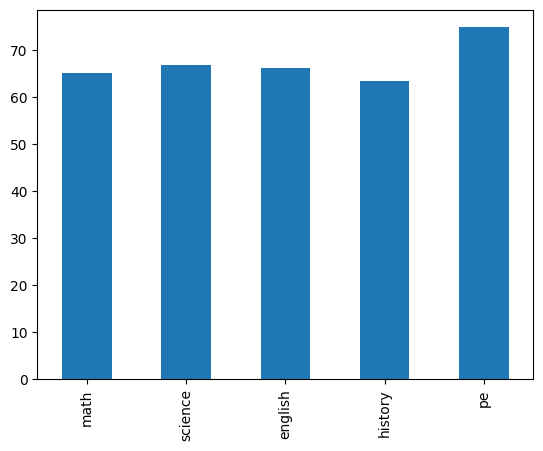

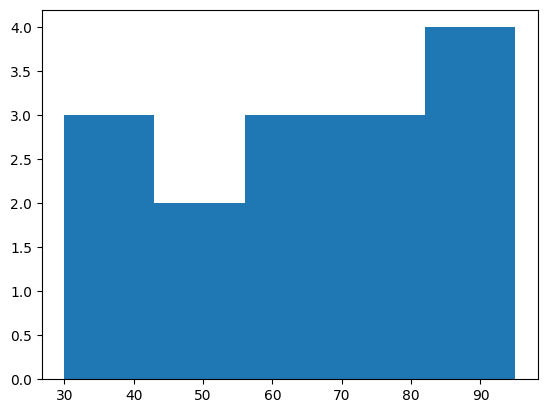

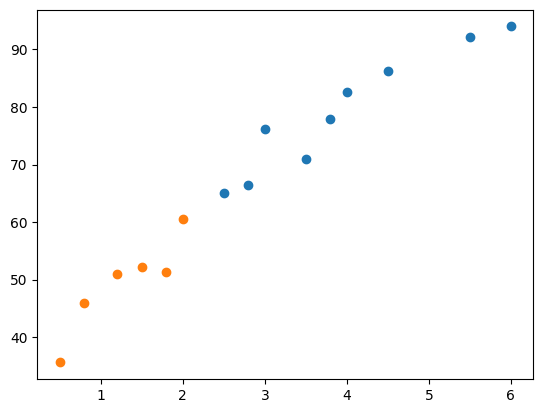

In [5]:
df[subjects].mean().plot(kind='bar')
plt.show()

plt.hist(df['math'], bins=5)
plt.show()

pass_students = df[df['passed']==1]
fail_students = df[df['passed']==0]

plt.scatter(pass_students['study_hours_per_day'], pass_students['avg_score'])
plt.scatter(fail_students['study_hours_per_day'], fail_students['avg_score'])
plt.show()

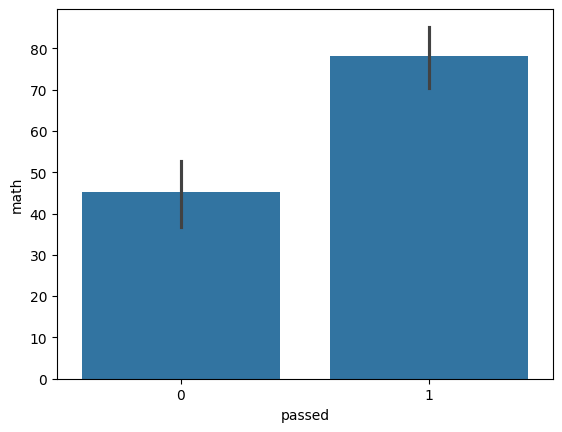

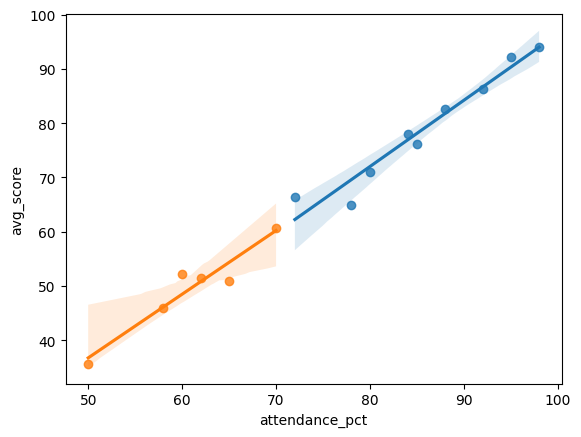

In [6]:
sns.barplot(data=df, x='passed', y='math')
plt.show()

sns.regplot(data=df[df['passed']==1], x='attendance_pct', y='avg_score')
sns.regplot(data=df[df['passed']==0], x='attendance_pct', y='avg_score')
plt.show()

In [7]:
X = df[['math','science','english','history','pe','attendance_pct','study_hours_per_day']]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

pred = model.predict(X_test_scaled)

accuracy_score(y_test, pred)

1.0

In [8]:
X = df[['math','science','english','history','pe','attendance_pct','study_hours_per_day']]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

pred = model.predict(X_test_scaled)

accuracy_score(y_test, pred)

1.0